# Analise 4 - Relação entre Horas de Sono e Indicativo de Depressão

## 1. Introdução
O sono é uma parte muito importante da rotina dos adolescentes, porque interfere diretamente no descanso, no humor, na disposição e até na forma como o jovem lida com o estresse do dia a dia. Dentro do contexto de saúde mental, dormir poucas horas pode estar relacionado a maiores sinais de desgaste psicológico. Esta análise investiga a relação entre a quantidade de horas de sono e o indicativo de depressão presente na base.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar o percentual de adolescentes com indicativo de depressão (`depression_label`) de acordo com as faixas de horas de sono (`sleep_hours`).
* Identificar se os adolescentes que dormem menos apresentam maior concentração de casos com indicativo de depressão na amostra analisada.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada dos arquivos fonte para construir o agrupamento e o gráfico de colunas:
* `dados_limpos.csv`: Base consolidada contendo as métricas de rotina, sono, redes sociais e saúde mental.

### 3.1 Carregamento e Pré-processamento dos Dados


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('../../bases/processed/dados_limpos.csv')


## 4. Gráficos e Insights

### 4.1 Faixas de Sono vs Percentual de Indicativo de Depressão
Nesta etapa, utilizamos um gráfico de colunas para comparar o percentual de adolescentes com indicativo de depressão de acordo com as faixas de sono:
* **Eixo X (Discreto):** Faixas de Horas de Sono (`sleep_hours`)
* **Eixo Y (Percentual):** Percentual de Indicativo de Depressão (`depression_label`)

**Hipótese:** As colunas devem apresentar valores maiores nas faixas de menor sono. Espera-se que os adolescentes que dormem menos horas registrem maior percentual de indicativo de depressão, pois a baixa quantidade de sono pode estar associada a maior desgaste emocional.


,faixa_sono,total,casos_depressao,percentual_depressao
0,Até 5h,240,20,8.333333
1,5h a 6h,240,11,4.583333
2,6h a 7h,241,0,0.000000
3,7h a 8h,241,0,0.000000
4,8h ou mais,238,0,0.000000


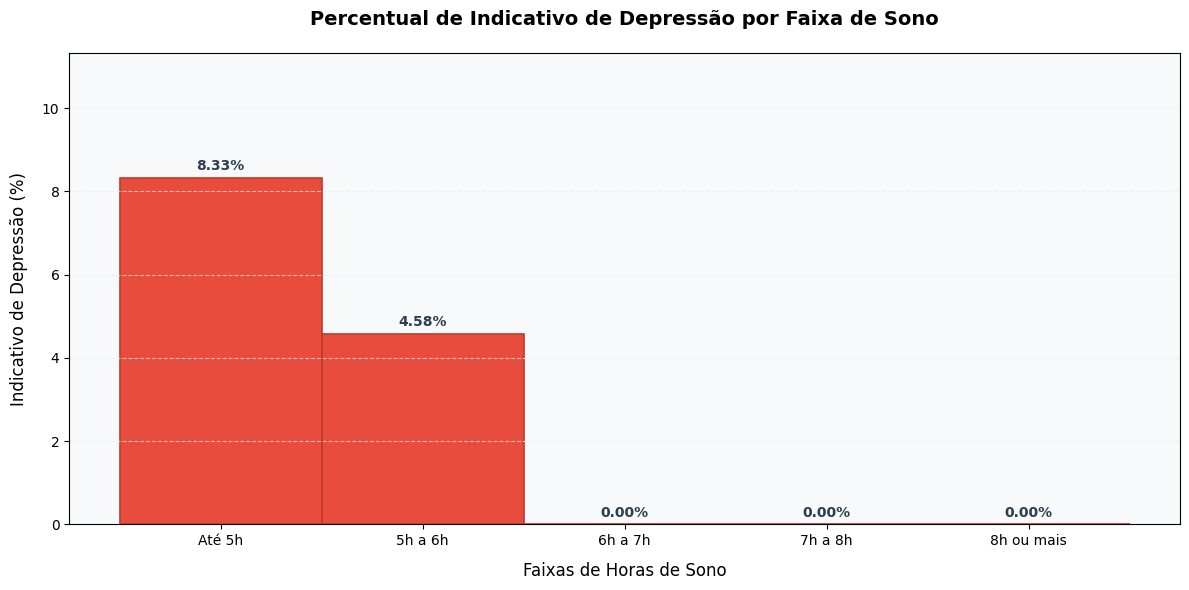

In [ ]:
# 1. Criar faixas de sono para facilitar a leitura da análise
faixas_sono = [0, 5, 6, 7, 8, 24]
rotulos_sono = ['Até 5h', '5h a 6h', '6h a 7h', '7h a 8h', '8h ou mais']

df['faixa_sono'] = pd.cut(
    df['sleep_hours'],
    bins=faixas_sono,
    labels=rotulos_sono,
    include_lowest=True,
    right=False
)

# 2. Agrupar os dados e calcular o percentual de depressão por faixa de sono
dados_sono = df.groupby('faixa_sono', observed=False).agg(
    total=('depression_label', 'size'),
    casos_depressao=('depression_label', 'sum'),
    percentual_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index()

# 3. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 4. Construção do Histograma (Gráfico de Colunas contínuas)
colunas = plt.bar(
    dados_sono['faixa_sono'].astype(str),
    dados_sono['percentual_depressao'],
    color='#e74c3c',
    edgecolor='#c0392b',
    linewidth=1.2,
    width=1.0  # Alterado de 0.5 para 1.0 para colar as barras, formato padrão do histograma
)

# 5. Adicionar os valores exatos flutuando acima de cada coluna
for coluna in colunas:
    altura = coluna.get_height()
    plt.annotate(
        f'{altura:.2f}%',
        xy=(coluna.get_x() + coluna.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 6. Customização de títulos e rótulos
plt.title('Percentual de Indicativo de Depressão por Faixa de Sono', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Faixas de Horas de Sono', fontsize=12, labelpad=10)
plt.ylabel('Indicativo de Depressão (%)', fontsize=12, labelpad=10)

# Define o limite do eixo Y com uma margem visual
plt.ylim(0, max(dados_sono['percentual_depressao']) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de colunas gerado, podemos apontar as seguintes conclusões sobre a relação entre sono e indicativo de depressão:

* **Maior Percentual nos Jovens que Dormem Menos:** O maior percentual de indicativo de depressão aparece na faixa de até 5 horas de sono, com aproximadamente 8.33% dos adolescentes desse grupo. Isso mostra que, dentro da amostra, os jovens que dormem menos concentram mais casos de depressão.
* **Redução na Faixa Seguinte:** Na faixa de 5h a 6h de sono, o percentual cai para cerca de 4.58%. Mesmo sendo menor do que o grupo anterior, ainda existe presença de indicativo de depressão nessa faixa, o que reforça que poucas horas de sono continuam sendo um ponto de atenção.
* **Ausência de Casos a Partir de 6 Horas:** A partir da faixa de 6h a 7h, o percentual fica em 0% na base analisada. Isso significa que, neste conjunto de dados, os casos com indicativo de depressão ficaram concentrados somente entre adolescentes que dormem menos de 6 horas.
* **Validação:** A hipótese de que menos horas de sono estão associadas a maior presença de indicativo de depressão foi **confirmada** na amostra. No total, a base possui 1200 registros e 31 casos com indicativo de depressão, o que representa cerca de 2.58% da amostra, e todos os casos concentrados abaixo das 6hrs de sono. Por isso, a análise mostra uma tendência importante, mas não permite afirmar causa e efeito.
